# Data Splitting & Scaling Pipeline — FT-Transformer Preparation

**Goal:** Split the engineered dataset into train/val/test sets, apply scaling without leakage, compute class weights, and apply SMOTE to minority classes.  
**Input:** `../data/processed/traffic_features_engineered.csv`  
**Output:** `../data/processed/splits/` and `../saved_models/`

**Note:** `StandardScaler` is fit exclusively on the training set and then applied to validation and test sets.  
This prevents test/validation statistics from leaking into the training distribution.

---

| Step | Action | Rationale |
|------|--------|-----------|
| 1 | Imports & configuration | Libraries and path constants |
| 2 | Data loading & target column detection | Load engineered dataset |
| 3 | Label encoding | Convert class names to integers (0 – N_CLASSES-1) |
| 4 | Feature / target separation | Build X and y arrays |
| 5 | Stratified train / val / test split | Preserve class balance across all three sets |
| 6 | StandardScaler + symmetry_index kontrolü | Fit on train only, check outlier features |
| 7 | Class weight computation | Compute weights for FocalLoss |
| 7a | SMOTE oversampling | Minority class augmentation on train set only |
| 8 | Validation | Verify shapes and class distributions |
| 9 | Export | Save splits, scaler, label encoder and class weights |


---

## 1. Imports & Configuration

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.size"         : 11,
})

DATA_PATH  = "../data/processed/traffic_features_engineered.csv"
SPLITS_DIR = "../data/processed/splits"
MODELS_DIR = "../saved_models"

TEST_SIZE    = 0.15
VAL_SIZE     = 0.15
RANDOM_STATE = 42

SMOTE_MIN_SUPPORT = 600 
SMOTE_TARGET      = 600 

os.makedirs(SPLITS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Libraries loaded.")
print(f"Split ratios  ->  Train: {round((1 - TEST_SIZE - VAL_SIZE) * 100)}%"
      f" | Val: {round(VAL_SIZE * 100)}%"
      f" | Test: {round(TEST_SIZE * 100)}%")


Libraries loaded.
Split ratios  ->  Train: 70% | Val: 15% | Test: 15%


---

## 2. Data Loading & Target Column Detection

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Input shape : {df.shape[0]:,} rows x {df.shape[1]} columns")

target_column = None
for col in df.columns:
    if col.lower() in ["traffic_type", "target", "label", "class"]:
        target_column = col
        break

if target_column is None:
    target_column = df.columns[-1]
    print(f"No named target column found. Using last column: '{target_column}'")
else:
    print(f"Target column detected: '{target_column}'")

print(f"\nClass distribution:")
print(df[target_column].value_counts())

Input shape : 40,985 rows x 15 columns
Target column detected: 'traffic_type'

Class distribution:
traffic_type
VPN-BROWSING     7315
BROWSING         6459
VOIP             6344
VPN-VOIP         5335
VPN-FT           3336
VPN-CHAT         2178
FT               2146
CHAT             2127
P2P              1950
VPN-STREAMING     835
MAIL              828
VPN-P2P           792
STREAMING         749
VPN-MAIL          591
Name: count, dtype: int64


---

## 3. Label Encoding

PyTorch `CrossEntropyLoss` expects integer targets in the range `[0, N_CLASSES - 1]`.  
Class names (`VOIP`, `VPN-BROWSING`, etc.) are mapped to integer indices here.

The fitted `LabelEncoder` is saved so predictions can be mapped back to class names during inference.

In [3]:
le = LabelEncoder()
y  = le.fit_transform(df[target_column])
print(f"Number of classes : {len(le.classes_)}")

Number of classes : 14


---

## 4. Feature / Target Separation

In [4]:
X = df.drop(columns=[target_column]).values.astype(np.float32)

print(f"X shape : {X.shape}  ->  ({X.shape[0]:,} samples, {X.shape[1]} features)")
print(f"y shape : {y.shape}")
print(f"\nFeature list ({X.shape[1]}):")
print(list(df.drop(columns=[target_column]).columns))

X shape : (40985, 14)  ->  (40,985 samples, 14 features)
y shape : (40985,)

Feature list (14):
['duration', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'std_active', 'bytes_per_pkt', 'log_duration', 'fiat_range', 'biat_range']


---

## 5. Stratified Train / Val / Test Split

With 14 classes and class imbalance present, `stratify=y` is required to preserve the class ratio in every set.  
The split is performed in two stages:

1. Full data  ->  **(Train + Val)** / **Test**  (85% / 15%)
2. Train + Val  ->  **Train** / **Val**  (70% / 15%)

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    stratify     = y,
    random_state = RANDOM_STATE,
)

val_size_adjusted = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size    = val_size_adjusted,
    stratify     = y_temp,
    random_state = RANDOM_STATE,
)

print("Split complete:")
print(f"  Train : {X_train.shape[0]:>6,} samples  ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"  Val   : {X_val.shape[0]:>6,} samples  ({X_val.shape[0]   / len(X) * 100:.1f}%)")
print(f"  Test  : {X_test.shape[0]:>6,} samples  ({X_test.shape[0]  / len(X) * 100:.1f}%)")

Split complete:
  Train : 28,689 samples  (70.0%)
  Val   :  6,148 samples  (15.0%)
  Test  :  6,148 samples  (15.0%)


---

## 6. StandardScaler

`StandardScaler` centres each feature to zero mean and unit variance, which is important for DNN weight initialisation and gradient flow.

**The scaler is fit on `X_train` only.**  
The same fitted scaler is then used to transform `X_val` and `X_test` without refitting.

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("StandardScaler applied.")
print(f"\nTrain set sample statistics after scaling (first 5 features):")
feature_names = list(df.drop(columns=[target_column]).columns)
print(pd.DataFrame(X_train[:, :5], columns=feature_names[:5])
        .describe().loc[["mean", "std"]].round(4))

if "symmetry_index" in feature_names:
    si_idx = feature_names.index("symmetry_index")
    si_vals = X_train[:, si_idx]
    print("\n[CHECK] symmetry_index statistics (after scaling):")
    print(f"  mean : {si_vals.mean():.4f}  (beklenen ~0)")
    print(f"  std  : {si_vals.std():.4f}   (beklenen ~1)")
    print(f"  min  : {si_vals.min():.4f}")
    print(f"  max  : {si_vals.max():.4f}")
    if abs(si_vals.std() - 1.0) > 0.3 or abs(si_vals.mean()) > 0.3:
        print(" WARNING: The symmetry_index distribution deviates from expectations. RobustScaler can be tried.")
    else:
        print("  OK: The symmetry_index distribution is within normal limits.")
else:
    print("\n[CHECK] symmetry_index does not exist in this dataset, check skipped.")


StandardScaler applied.

Train set sample statistics after scaling (first 5 features):
      duration  total_biat  min_fiat  min_biat  max_fiat
mean       0.0         0.0       0.0       0.0       0.0
std        1.0         1.0       1.0       1.0       1.0

[CHECK] symmetry_index does not exist in this dataset, check skipped.


---

## 7. Class Imbalance Handling (Weights + SMOTE)

`WeightedCrossEntropyLoss` uses class weights (computed **only from the training set**) to handle imbalance:
`nn.CrossEntropyLoss(weight=torch.FloatTensor(np.load('saved_models/class_weights.npy')))`

For low-support classes (e.g., Class 11), weights alone may be insufficient. **SMOTE** is applied to `X_train` / `y_train` to generate synthetic samples and improve class boundaries.

**Rule:** Apply SMOTE **only on training data**. Do not modify `X_val` or `X_test` (prevents data leakage).

In [7]:
train_counts = np.bincount(y_train)
smote_targets = {
    int(cls): SMOTE_TARGET
    for cls, cnt in enumerate(train_counts)
    if cnt < SMOTE_MIN_SUPPORT
}

if smote_targets:
    print("SMOTETomek uygulanacak sınıflar:")
    for cls_idx, target in smote_targets.items():
        cls_name = le.classes_[cls_idx] if cls_idx < len(le.classes_) else str(cls_idx)
        print(f"  [{cls_idx:>2}] {cls_name:<20}  {train_counts[cls_idx]:>4} -> {target}")

    smote_tomek = SMOTETomek(
        sampling_strategy=smote_targets,
        random_state=RANDOM_STATE,
        tomek=TomekLinks(sampling_strategy='all'),
        n_jobs=-1
    )

    X_train, y_train = smote_tomek.fit_resample(X_train, y_train)

    print(f"\nAfter SMOTE Tomek X_train shape : {X_train.shape}")
    print("Yeni sınıf dağılımı (train):")
    new_counts = np.bincount(y_train)
    for cls_idx, cnt in enumerate(new_counts):
        cls_name = le.classes_[cls_idx] if cls_idx < len(le.classes_) else str(cls_idx)
        marker = " <-- SMOTETomek (Temizlenmiş)" if cls_idx in smote_targets else ""
        print(f"  [{cls_idx:>2}] {cls_name:<20}  {cnt}{marker}")
else:
    print(f"Tüm sınıflar {SMOTE_MIN_SUPPORT}+ örnekten fazla — SMOTE uygulanmadı.")

SMOTETomek uygulanacak sınıflar:
  [ 3] MAIL                   580 -> 600
  [ 5] STREAMING              525 -> 600
  [10] VPN-MAIL               413 -> 600
  [11] VPN-P2P                554 -> 600
  [12] VPN-STREAMING          585 -> 600

After SMOTE Tomek X_train shape : (27678, 14)
Yeni sınıf dağılımı (train):
  [ 0] BROWSING              4287
  [ 1] CHAT                  1362
  [ 2] FT                    1453
  [ 3] MAIL                  567 <-- SMOTETomek (Temizlenmiş)
  [ 4] P2P                   1334
  [ 5] STREAMING             552 <-- SMOTETomek (Temizlenmiş)
  [ 6] VOIP                  4365
  [ 7] VPN-BROWSING          4846
  [ 8] VPN-CHAT              1381
  [ 9] VPN-FT                2201
  [10] VPN-MAIL              569 <-- SMOTETomek (Temizlenmiş)
  [11] VPN-P2P               540 <-- SMOTETomek (Temizlenmiş)
  [12] VPN-STREAMING         581 <-- SMOTETomek (Temizlenmiş)
  [13] VPN-VOIP              3640


In [8]:
class_weights = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(y_train),
    y            = y_train,
)

print("Class weights computed from training set:")
print("-" * 42)
for idx, (cls_name, weight) in enumerate(zip(le.classes_, class_weights)):
    print(f"  [{idx:>2}] {cls_name:<20}  {weight:.4f}")

np.save(os.path.join(MODELS_DIR, "class_weights.npy"), class_weights)
print(f"\nSaved to : '{MODELS_DIR}/class_weights.npy'")

Class weights computed from training set:
------------------------------------------
  [ 0] BROWSING              0.4612
  [ 1] CHAT                  1.4515
  [ 2] FT                    1.3606
  [ 3] MAIL                  3.4868
  [ 4] P2P                   1.4820
  [ 5] STREAMING             3.5815
  [ 6] VOIP                  0.4529
  [ 7] VPN-BROWSING          0.4080
  [ 8] VPN-CHAT              1.4316
  [ 9] VPN-FT                0.8982
  [10] VPN-MAIL              3.4745
  [11] VPN-P2P               3.6611
  [12] VPN-STREAMING         3.4028
  [13] VPN-VOIP              0.5431

Saved to : '../saved_models/class_weights.npy'


---

## 8. Validation

Confirming that the stratified split preserved class proportions across all three sets.

In [9]:
print("Array shapes:")
print(f"  X_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Array shapes:
  X_train : (27678, 14)    y_train : (27678,)
  X_val   : (6148, 14)    y_val   : (6148,)
  X_test  : (6148, 14)    y_test  : (6148,)


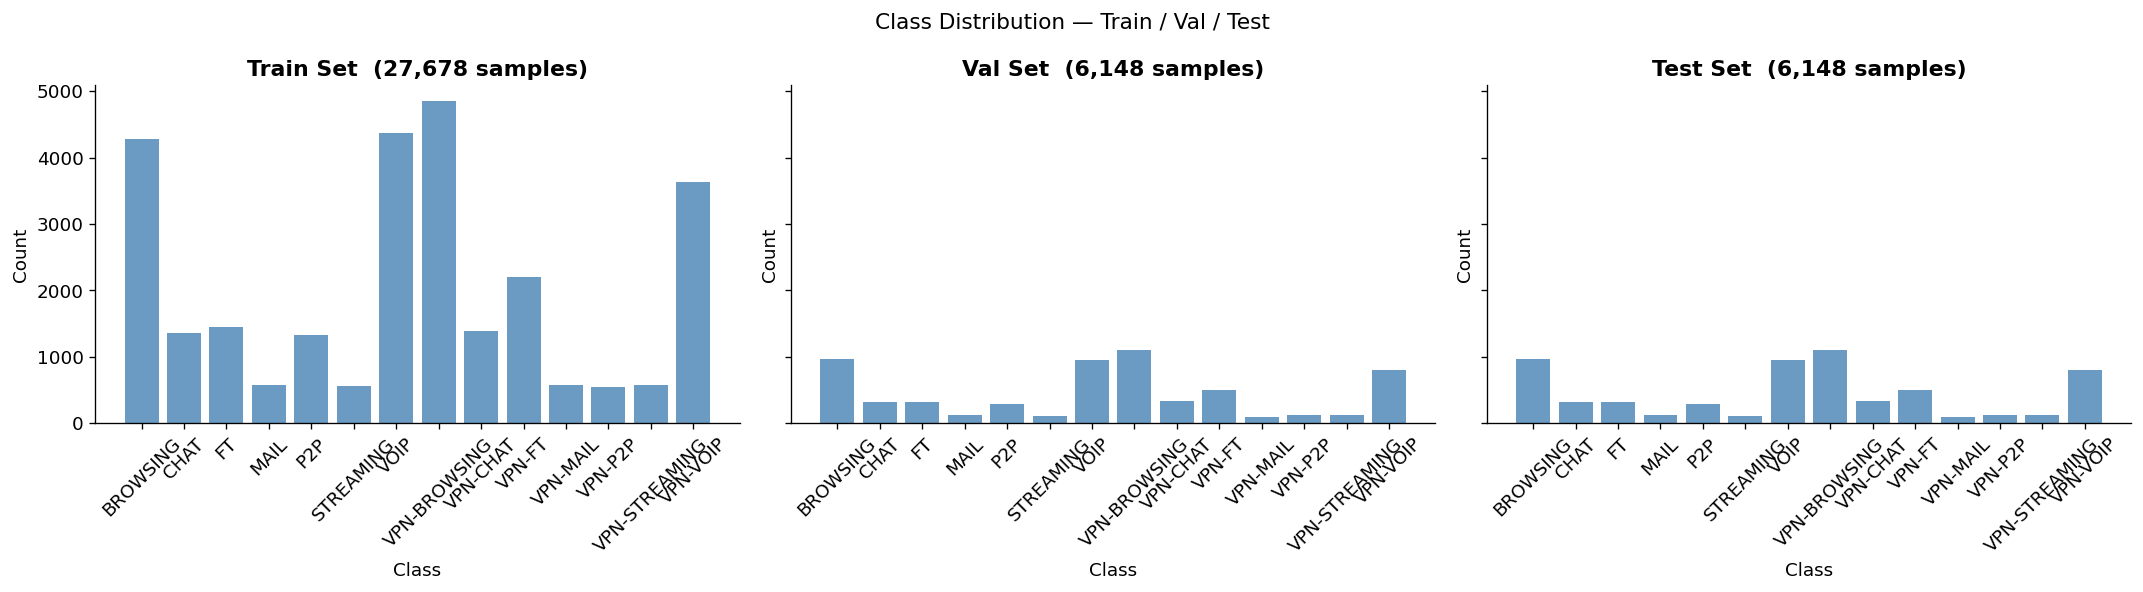

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (split_y, split_name) in zip(axes, [(y_train, "Train"), (y_val, "Val"), (y_test, "Test")]):
    counts = pd.Series(split_y).value_counts().sort_index()
    ax.bar(le.classes_, counts.values, color="steelblue", alpha=0.8)
    ax.set_title(f"{split_name} Set  ({len(split_y):,} samples)", fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Class Distribution — Train / Val / Test", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
dist_df = pd.DataFrame({
    "Class"       : le.classes_,
    "Train (n)"   : [np.sum(y_train == i) for i in range(len(le.classes_))],
    "Val (n)"     : [np.sum(y_val   == i) for i in range(len(le.classes_))],
    "Test (n)"    : [np.sum(y_test  == i) for i in range(len(le.classes_))],
})
dist_df["Train (%)"] = (dist_df["Train (n)"] / len(y_train) * 100).round(2)
dist_df["Val (%)"]   = (dist_df["Val (n)"]   / len(y_val)   * 100).round(2)
dist_df["Test (%)"]  = (dist_df["Test (n)"]  / len(y_test)  * 100).round(2)

print(dist_df.to_string(index=False))

        Class  Train (n)  Val (n)  Test (n)  Train (%)  Val (%)  Test (%)
     BROWSING       4287      969       969      15.49    15.76     15.76
         CHAT       1362      319       319       4.92     5.19      5.19
           FT       1453      322       322       5.25     5.24      5.24
         MAIL        567      124       124       2.05     2.02      2.02
          P2P       1334      292       293       4.82     4.75      4.77
    STREAMING        552      112       112       1.99     1.82      1.82
         VOIP       4365      952       952      15.77    15.48     15.48
 VPN-BROWSING       4846     1097      1097      17.51    17.84     17.84
     VPN-CHAT       1381      327       327       4.99     5.32      5.32
       VPN-FT       2201      501       500       7.95     8.15      8.13
     VPN-MAIL        569       89        89       2.06     1.45      1.45
      VPN-P2P        540      119       119       1.95     1.94      1.94
VPN-STREAMING        581      125     

---

## 9. Export

| File | Description |
|------|-------------|
| `splits/X_train.npy` | Scaled training features |
| `splits/X_val.npy` | Scaled validation features |
| `splits/X_test.npy` | Scaled test features |
| `splits/y_train.npy` | Training labels (integer) |
| `splits/y_val.npy` | Validation labels (integer) |
| `splits/y_test.npy` | Test labels (integer) |
| `saved_models/scaler.pkl` | Fitted `StandardScaler` for inference |
| `saved_models/label_encoder.pkl` | Fitted `LabelEncoder` for decoding predictions |
| `saved_models/class_weights.npy` | Class weights for `WeightedCrossEntropyLoss` |

In [12]:
np.save(os.path.join(SPLITS_DIR, "X_train.npy"), X_train)
np.save(os.path.join(SPLITS_DIR, "X_val.npy"),   X_val)
np.save(os.path.join(SPLITS_DIR, "X_test.npy"),  X_test)
np.save(os.path.join(SPLITS_DIR, "y_train.npy"), y_train)
np.save(os.path.join(SPLITS_DIR, "y_val.npy"),   y_val)
np.save(os.path.join(SPLITS_DIR, "y_test.npy"),  y_test)
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
joblib.dump(le,     os.path.join(MODELS_DIR, "label_encoder.pkl"))

print("All files saved.")
print(f"  Splits  -> '{SPLITS_DIR}/'")
print(f"  Scaler  -> '{MODELS_DIR}/scaler.pkl'")
print(f"  Encoder -> '{MODELS_DIR}/label_encoder.pkl'")
print(f"  Weights -> '{MODELS_DIR}/class_weights.npy'")

All files saved.
  Splits  -> '../data/processed/splits/'
  Scaler  -> '../saved_models/scaler.pkl'
  Encoder -> '../saved_models/label_encoder.pkl'
  Weights -> '../saved_models/class_weights.npy'
